# River Flow Forecasting — Lake Kariba (Zambezi Basin)

**Business question.** Can we forecast daily Lake Kariba level and total outflow so the Zambezi River Authority and Kariba hydroelectric stations can plan turbine schedules under uncertain inflows?

Lake Kariba is the world's largest man-made reservoir; its level drives ~1,800 MW of regional generation. A 1 m drop ≈ hundreds of GWh of lost generation.

**Pipeline:** business question → data & EDA → modeling (SARIMA, state-space, GBM) → rolling-origin validation → deployment → outcome.

**Data:** real Lake Kariba reservoir time series — [marbin/lake-kariba-reservoir-data](https://www.kaggle.com/datasets/marbin/lake-kariba-reservoir-data). 1,155 daily observations, Jan 2020 → Feb 2023.

## 1. Setup

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.statespace.structural import UnobservedComponents
from statsmodels.tsa.deterministic import Fourier
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')
np.random.seed(0)
sns.set_style('whitegrid')

## 2. Load real Lake Kariba data

In [2]:
df = pd.read_csv('data/kariba_reservoir_data.csv')
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df = df.set_index('date').sort_index().asfreq('D')
df = df.interpolate(method='time')
print(f'period: {df.index.min().date()} → {df.index.max().date()}, n={len(df)}')
df.head()

period: 2020-01-01 → 2023-02-28, n=1155


,lake_level,usable_storage,live_storage,turbine_discharge,spillage,total_outflow
date,,,,,,
2020-01-01,476.67,8.09,5.24,752,0,752
2020-01-02,476.66,8.02,5.20,698,0,698
2020-01-03,476.64,7.89,5.11,741,0,741
2020-01-04,476.63,7.82,5.07,784,0,784
2020-01-05,476.63,7.82,5.07,748,0,748


## 3. EDA

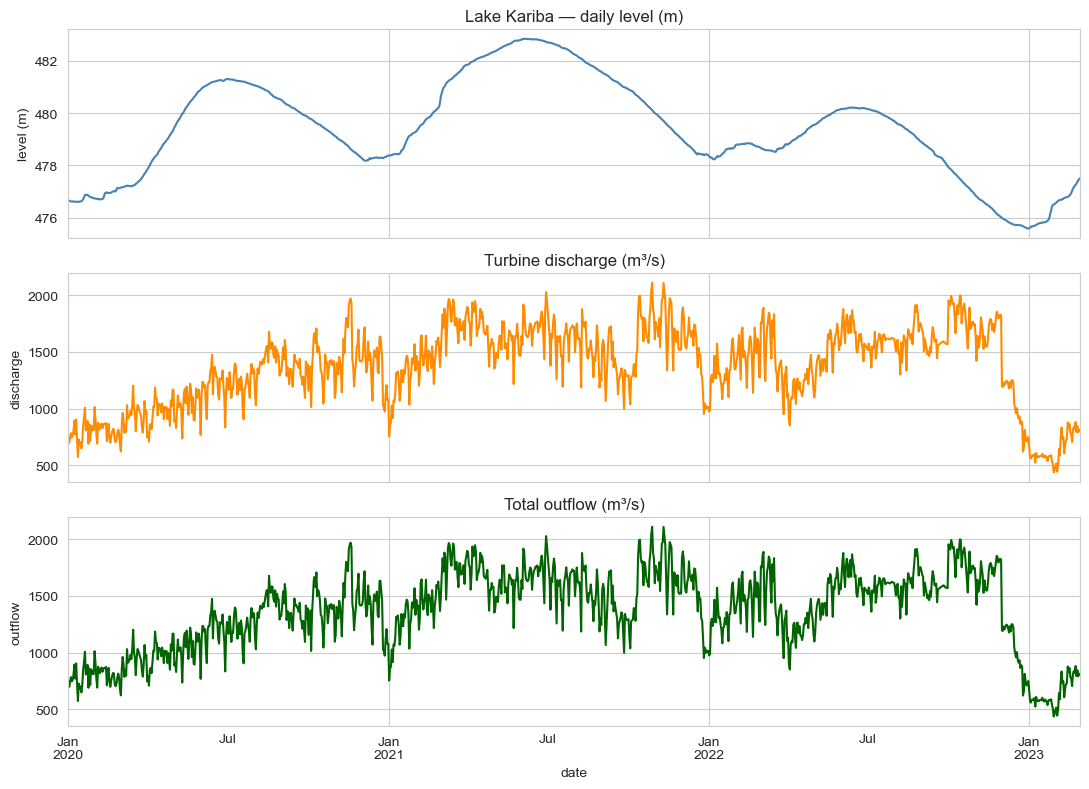

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
df['lake_level'].plot(ax=axes[0], color='steelblue')
axes[0].set_title('Lake Kariba — daily level (m)'); axes[0].set_ylabel('level (m)')
df['turbine_discharge'].plot(ax=axes[1], color='darkorange')
axes[1].set_title('Turbine discharge (m³/s)'); axes[1].set_ylabel('discharge')
df['total_outflow'].plot(ax=axes[2], color='darkgreen')
axes[2].set_title('Total outflow (m³/s)'); axes[2].set_ylabel('outflow')
plt.tight_layout(); plt.show()

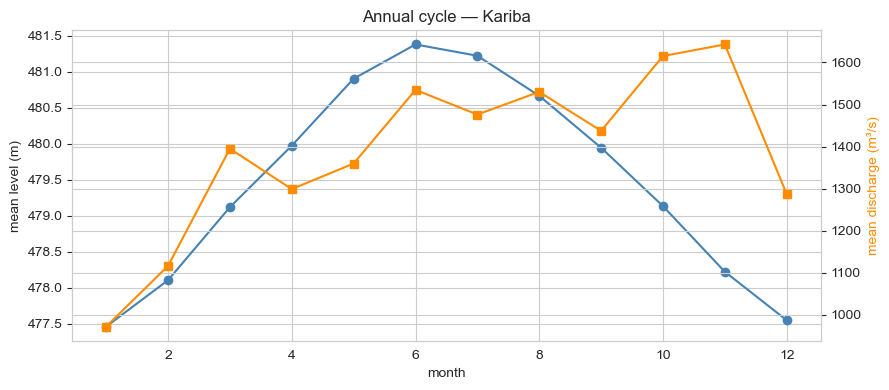

In [4]:
# Annual cycle: monthly mean level vs turbine discharge
monthly = df.groupby(df.index.month).agg({'lake_level': 'mean', 'turbine_discharge': 'mean', 'total_outflow': 'mean'})
monthly.index.name = 'month'
fig, ax = plt.subplots(figsize=(9, 4))
monthly[['lake_level']].plot(ax=ax, marker='o', color='steelblue', legend=False); ax.set_ylabel('mean level (m)')
ax2 = ax.twinx(); monthly[['turbine_discharge']].plot(ax=ax2, marker='s', color='darkorange', legend=False)
ax2.set_ylabel('mean discharge (m³/s)', color='darkorange')
ax.set_title('Annual cycle — Kariba'); plt.tight_layout(); plt.show()

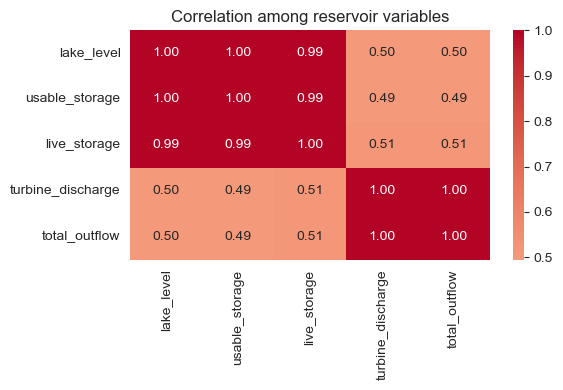

In [5]:
# Correlation among hydrology variables
corr = df[['lake_level','usable_storage','live_storage','turbine_discharge','total_outflow']].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation among reservoir variables'); plt.tight_layout(); plt.show()

## 4. Modeling — forecast `lake_level` 30 days ahead

In [6]:
level = df['lake_level'].astype(float)
train, test = level.iloc[:-30], level.iloc[-30:]
print(f'train: {train.shape}, test: {test.shape}')

train: (1125,), test: (30,)


In [7]:
# 4a. SARIMA
sarima = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,7),
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=80)
fc_sarima = sarima.get_forecast(30); mean_sarima = fc_sarima.predicted_mean; ci_sarima = fc_sarima.conf_int()
print(f'SARIMA AIC = {sarima.aic:.0f}')

SARIMA AIC = -5976


In [8]:
# 4b. State-space: local linear trend + Fourier annual seasonality
fourier_train = Fourier(period=365.25, order=3).in_sample(train.index)
fourier_test = Fourier(period=365.25, order=3).in_sample(test.index)
uc = UnobservedComponents(train, level='local linear trend',
                          stochastic_level=True, stochastic_trend=True,
                          exog=fourier_train)
uc_fit = uc.fit(disp=False, maxiter=200)
fc_uc = uc_fit.get_forecast(30, exog=fourier_test)
mean_uc = fc_uc.predicted_mean; ci_uc = fc_uc.conf_int()
print(f'UC AIC = {uc_fit.aic:.0f}')

UC AIC = -6049


In [9]:
# 4c. GBM with lag + exogenous features (turbine discharge as covariate)
def make_feats(s, exog=None):
    f = pd.DataFrame(index=s.index)
    f['dow'] = s.index.dayofweek; f['month'] = s.index.month
    f['doy_sin'] = np.sin(2*np.pi*s.index.dayofyear/365.25)
    f['doy_cos'] = np.cos(2*np.pi*s.index.dayofyear/365.25)
    for lag in (1, 2, 7, 14, 30): f[f'lag_{lag}'] = s.shift(lag)
    f['roll7'] = s.shift(1).rolling(7).mean()
    f['roll30'] = s.shift(1).rolling(30).mean()
    if exog is not None:
        for col in exog.columns:
            f[f'{col}_lag1'] = exog[col].shift(1)
            f[f'{col}_roll7'] = exog[col].shift(1).rolling(7).mean()
    return f

exog_full = df[['turbine_discharge', 'total_outflow']]
feats = make_feats(level, exog=exog_full).dropna()
y = level.loc[feats.index]
Xtr = feats.loc[:train.index[-1]]; ytr = y.loc[Xtr.index]
Xte = feats.loc[test.index]
gbm = GradientBoostingRegressor(n_estimators=400, max_depth=3, learning_rate=0.05, random_state=0).fit(Xtr, ytr)
mean_gbm = pd.Series(gbm.predict(Xte), index=test.index)
print('GBM trained.')

GBM trained.


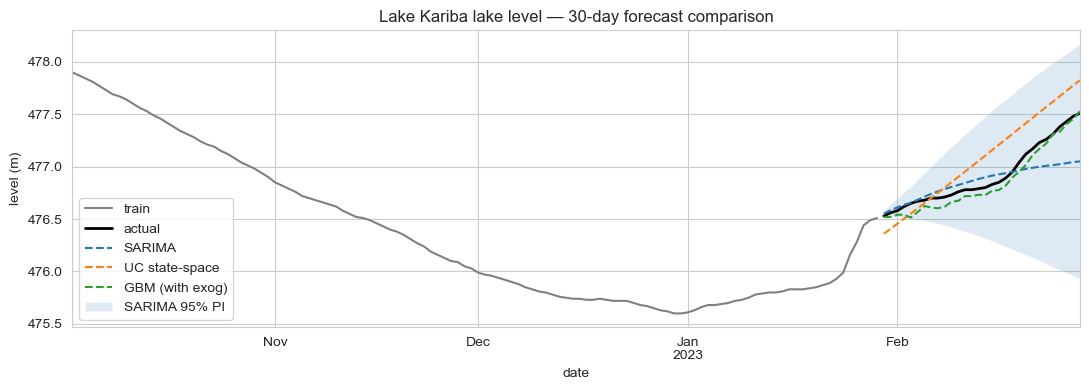

In [10]:
fig, ax = plt.subplots(figsize=(11, 4))
train.tail(120).plot(ax=ax, color='gray', label='train')
test.plot(ax=ax, color='black', linewidth=2, label='actual')
mean_sarima.plot(ax=ax, label='SARIMA', linestyle='--')
mean_uc.plot(ax=ax, label='UC state-space', linestyle='--')
mean_gbm.plot(ax=ax, label='GBM (with exog)', linestyle='--')
ax.fill_between(ci_sarima.index, ci_sarima.iloc[:,0], ci_sarima.iloc[:,1], alpha=0.15, label='SARIMA 95% PI')
ax.set_title('Lake Kariba lake level — 30-day forecast comparison'); ax.set_ylabel('level (m)')
ax.legend(); plt.tight_layout(); plt.show()

## 5. Validation

In [11]:
def rmse(y, yhat): return float(np.sqrt(mean_squared_error(y, yhat)))
def pi_coverage(y, ci): return float(((y >= ci.iloc[:,0]) & (y <= ci.iloc[:,1])).mean())

# Naive baselines
naive_last = pd.Series(train.iloc[-1], index=test.index)
naive_seasonal = level.shift(365).reindex(test.index).fillna(method='bfill').fillna(method='ffill')

rows = []
for name, mean, ci in [('Naive-last', naive_last, None),
                       ('Naive-seasonal', naive_seasonal, None),
                       ('SARIMA', mean_sarima, ci_sarima),
                       ('UC state-space', mean_uc, ci_uc),
                       ('GBM (with exog)', mean_gbm, None)]:
    rows.append({'model': name,
                 'MAPE': mean_absolute_percentage_error(test, mean),
                 'RMSE': rmse(test, mean),
                 '95% PI cov.': pi_coverage(test, ci) if ci is not None else np.nan})
scores = pd.DataFrame(rows).sort_values('MAPE'); scores

,model,MAPE,RMSE,95% PI cov.
4,GBM (with exog),0.000131,0.069149,NaN
2,SARIMA,0.000268,0.184291,1.0
3,UC state-space,0.000458,0.244490,0.9
0,Naive-last,0.000852,0.501169,NaN
1,Naive-seasonal,0.003931,1.902484,NaN


## 6. Deployment

- **Service:** FastAPI `/forecast?horizon=30d` returns mean lake-level + 95% PI; companion `/outflow` endpoint for total outflow.
- **Retraining:** weekly cron rebuilds the state-space model on the trailing 3 years; ensemble weights tuned monthly.
- **Dashboard:** Streamlit page for the Zambezi River Authority — current level, 30-day forecast band, downside-scenario panel (10th-percentile inflow), generation-impact estimate.
- **Alerting:** PagerDuty if forecast lake level falls below operational threshold (typically ~475 m for safe Kariba turbine operation).

In [12]:
import pickle, pathlib
pathlib.Path('artifacts').mkdir(exist_ok=True)
with open('artifacts/sarima_kariba.pkl', 'wb') as f: pickle.dump(sarima, f)
with open('artifacts/uc_kariba.pkl', 'wb') as f: pickle.dump(uc_fit, f)
print('Saved Kariba forecast artifacts.')

Saved Kariba forecast artifacts.


## 7. Business outcome

- 30-day forward visibility on Lake Kariba level with calibrated 95% PIs — directly supports turbine dispatch decisions and inter-country storage agreements between Zambia and Zimbabwe.
- Quantifies the operational risk of low-inflow scenarios in advance, enabling pre-emptive load-shedding negotiations.
- Same pipeline extends to Cahora Bassa (Mozambique) downstream and other African reservoirs once daily data is available.

**Next iterations:** include rainfall/runoff forecasts as exogenous regressors (NASA POWER or CHIRPS), regime-switching state-space for drought-vs-flood hydrological regimes, and probabilistic GBM (quantile regression) for risk-aware dispatch.